In [1]:
# Install required packages for pure PyTorch implementation
# Run this cell if you haven't installed the required packages

# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install scikit-learn pillow matplotlib numpy
# !pip install scikit-image tqdm

print("Required packages for this notebook:")
print("- torch, torchvision, torchaudio")
print("- scikit-learn")
print("- pillow (PIL)")
print("- matplotlib")
print("- numpy")
print("- scikit-image")
print("- tqdm (for progress bars)")
print("- pandas (optional)")
print("\nTo install, uncomment and run the pip install commands above.")

Required packages for this notebook:
- torch, torchvision, torchaudio
- scikit-learn
- pillow (PIL)
- matplotlib
- numpy
- scikit-image
- tqdm (for progress bars)
- pandas (optional)

To install, uncomment and run the pip install commands above.


In [2]:
# Install tqdm for progress bars
try:
    from tqdm.auto import tqdm
    print("✅ tqdm already installed")
except ImportError:
    print("📦 Installing tqdm...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm"])
    from tqdm.auto import tqdm
    print("✅ tqdm installed successfully!")

# Test tqdm
import time
print("\n🧪 Testing progress bar:")
for i in tqdm(range(5), desc="Testing"):
    time.sleep(0.1)
print("🎉 Progress bar working correctly!")

✅ tqdm already installed

🧪 Testing progress bar:


Testing:   0%|          | 0/5 [00:00<?, ?it/s]

🎉 Progress bar working correctly!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v3_large, mobilenet_v3_small
print("GPU available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current CUDA device:", torch.cuda.current_device())
    print("CUDA device name:", torch.cuda.get_device_name())

GPU available: True
CUDA device count: 1
Current CUDA device: 0
CUDA device name: NVIDIA GeForce RTX 5070 Ti


In [4]:
# Thiết lập device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Hyperparameters
monitor='val_accuracy'
epochs=40
batch_size=16
input_shape=(160, 160, 3)  # MobileNetV3 works better with 224x224
Verbose=True
learning_rate=0.001
num_classes=15

This source code requires a **HIGH RAM** machine.

You might need to install this on your system:

apt-get install python3-opencv git

For PyTorch: pip install torch torchvision torchaudio

In [6]:
import os

# if not os.path.isdir('k'):
#   !git clone https://github.com/joaopauloschuler/k-neural-api.git k
# else:
#   !cd k && git pull

# !cd k && pip install .

In [7]:
import sys
print("Python version")
print (sys.version)
print("Version info.")
print (sys.version_info)
import importlib
import skimage
print('skimage version',  skimage.__version__)
import torch
import torchvision
print('PyTorch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)

# Pure PyTorch implementation - no CAI dependencies
print("Using pure PyTorch implementation!")

Python version
3.10.11 | packaged by Anaconda, Inc. | (main, May 16 2023, 00:55:32) [MSC v.1916 64 bit (AMD64)]
Version info.
sys.version_info(major=3, minor=10, micro=11, releaselevel='final', serial=0)
skimage version 0.25.2
PyTorch version: 2.7.1+cu128
Torchvision version: 0.22.1+cu128
Using pure PyTorch implementation!


In [8]:
# url_zip_file="https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/d5652a28-c1d8-4b76-97f3-72fb80f94efc/file_downloaded"
# local_zip_file="plant_leaf.zip"
# expected_folder_name="plant_leaf"
# cai.datasets.download_zip_and_extract(
#     url_zip_file=url_zip_file, local_zip_file=local_zip_file, 
#     expected_folder_name=expected_folder_name, Verbose=Verbose)

In [9]:
import random
import os
import multiprocessing
import glob
import numpy as np
from sklearn.model_selection import train_test_split
import sklearn.utils.class_weight
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v3_large, mobilenet_v3_small
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
%matplotlib inline

In [10]:
# !rm -r plant_leaf/Plant_leave_diseases_dataset_without_augmentation/Background_without_leaves -R
data_dir = "dataset/PlantVillage"
print(os.listdir(data_dir))

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [11]:
# Pure PyTorch data loading function
def load_images_from_folders_pytorch(root_dir, seed=7, training_size=0.6, validation_size=0.2, test_size=0.2,
                                    target_size=(160, 160), verbose=True):
    """
    Pure PyTorch implementation to replace cai.datasets.load_images_from_folders
    """
    import random
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelBinarizer
    import sklearn.utils.class_weight
    
    # Set random seed
    random.seed(seed)
    np.random.seed(seed)
    
    images = []
    labels = []
    classes = []
    
    # Load images and labels from folders
    for class_name in sorted(os.listdir(root_dir)):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            classes.append(class_name)
            class_idx = len(classes) - 1
            
            if verbose:
                print(f"Loading class: {class_name}")
            
            class_images = []
            for img_file in os.listdir(class_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_path, img_file)
                    try:
                        img = Image.open(img_path).convert('RGB')
                        img = img.resize(target_size)
                        img_array = np.array(img)  # Keep in [0,255] - transforms will normalize
                        class_images.append(img_array)
                    except Exception as e:
                        if verbose:
                            print(f"Error loading {img_path}: {e}")
            
            # Add all images from this class
            images.extend(class_images)
            labels.extend([class_idx] * len(class_images))
            
            if verbose:
                print(f"Loaded {len(class_images)} images from {class_name}")
    
    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)
    
    if verbose:
        print(f"Total images loaded: {len(images)}")
        print(f"Image shape: {images.shape}")
        print(f"Classes: {classes}")
    
    # Convert labels to one-hot encoding
    lb = LabelBinarizer()
    labels_onehot = lb.fit_transform(labels)
    
    # Split data: first split into train and temp (val+test)
    temp_size = validation_size + test_size
    train_x, temp_x, train_y, temp_y = train_test_split(
        images, labels_onehot, test_size=temp_size, random_state=seed, stratify=labels
    )
    
    # Split temp into validation and test
    val_ratio = validation_size / temp_size
    val_x, test_x, val_y, test_y = train_test_split(
        temp_x, temp_y, test_size=(1 - val_ratio), random_state=seed, stratify=np.argmax(temp_y, axis=1)
    )
    
    # Calculate class weights for handling imbalanced data
    class_weights = sklearn.utils.class_weight.compute_class_weight(
        'balanced', classes=np.unique(labels), y=labels
    )
    classweight = dict(enumerate(class_weights))
    
    if verbose:
        print(f"Train set: {train_x.shape}")
        print(f"Validation set: {val_x.shape}")
        print(f"Test set: {test_x.shape}")
        print(f"Class weights: {classweight}")
    
    return train_x, val_x, test_x, train_y, val_y, test_y, classweight, classes

# Load data using pure PyTorch implementation
train_x, val_x, test_x, train_y, val_y, test_y, classweight, classes = load_images_from_folders_pytorch(
    root_dir=data_dir, 
    seed=7,
    training_size=0.6, 
    validation_size=0.2, 
    test_size=0.2,
    target_size=(input_shape[0], input_shape[1]), 
    verbose=Verbose
)

Loading class: Pepper__bell___Bacterial_spot
Loaded 997 images from Pepper__bell___Bacterial_spot
Loading class: Pepper__bell___healthy
Loaded 997 images from Pepper__bell___Bacterial_spot
Loading class: Pepper__bell___healthy
Loaded 1478 images from Pepper__bell___healthy
Loading class: Potato___Early_blight
Loaded 1478 images from Pepper__bell___healthy
Loading class: Potato___Early_blight
Loaded 1000 images from Potato___Early_blight
Loading class: Potato___Late_blight
Loaded 1000 images from Potato___Early_blight
Loading class: Potato___Late_blight
Loaded 1000 images from Potato___Late_blight
Loading class: Potato___healthy
Loaded 152 images from Potato___healthy
Loading class: Tomato_Bacterial_spot
Loaded 1000 images from Potato___Late_blight
Loading class: Potato___healthy
Loaded 152 images from Potato___healthy
Loading class: Tomato_Bacterial_spot
Loaded 2127 images from Tomato_Bacterial_spot
Loading class: Tomato_Early_blight
Loaded 2127 images from Tomato_Bacterial_spot
Loadin

In [12]:
print(classes)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [13]:
print(train_x.shape,val_x.shape,test_x.shape)
print(train_y.shape,val_y.shape,test_y.shape)

(12382, 160, 160, 3) (4128, 160, 160, 3) (4128, 160, 160, 3)
(12382, 15) (4128, 15) (4128, 15)


In [14]:
# Custom Dataset class for PyTorch - Fixed for consistency
class PlantDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image = self.images[idx]
        label = np.argmax(self.labels[idx])  # Convert from one-hot to class index
        
        # Convert numpy array to PIL Image
        if isinstance(image, np.ndarray):
            # Ensure image is in uint8 [0,255] range
            if image.dtype != np.uint8:
                if image.max() <= 1.0:
                    image = (image * 255).astype(np.uint8)
                else:
                    image = image.astype(np.uint8)
            image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [15]:
# Data transforms - consistent with train.ipynb (160x160)
train_transform = transforms.Compose([
    transforms.Resize((160, 160)),  # Match train.ipynb size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),  # This converts [0,255] -> [0,1] AND HWC -> CHW
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((160, 160)),  # Match train.ipynb size
    transforms.ToTensor(),  # This converts [0,255] -> [0,1] AND HWC -> CHW
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = PlantDataset(train_x, train_y, transform=train_transform)
val_dataset = PlantDataset(val_x, val_y, transform=val_test_transform)
test_dataset = PlantDataset(test_x, test_y, transform=val_test_transform)

# Create data loaders - optimized settings
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [16]:
# Debug: Check data consistency with train.ipynb
print("🔍 Data Consistency Check:")
print(f"Input shape setting: {input_shape}")
print(f"Target size for loading: ({input_shape[0]}, {input_shape[1]})")

# Check a few samples from the dataset
for i in range(2):
    image, label = train_dataset[i]
    print(f"\nSample {i+1}:")
    print(f"  Image tensor shape: {image.shape}")
    print(f"  Image tensor range: [{image.min():.3f}, {image.max():.3f}]")
    print(f"  Label: {label} -> {classes[label]}")

# Check if data matches expected range after transforms
print(f"\n📊 After transforms:")
print(f"  Expected range: ImageNet normalized (~ [-2, 2])")
print(f"  Actual range: [{image.min():.3f}, {image.max():.3f}]")

print(f"\n✅ Data loading completed. Ready for training with:")
print(f"  - Image size: 160x160 (matching train.ipynb)")
print(f"  - Batch size: {batch_size}")
print(f"  - Epochs: {epochs}")
print(f"  - Classes: {len(classes)}")

🔍 Data Consistency Check:
Input shape setting: (160, 160, 3)
Target size for loading: (160, 160)

Sample 1:
  Image tensor shape: torch.Size([3, 160, 160])
  Image tensor range: [-1.895, 1.333]
  Label: 14 -> Tomato_healthy

Sample 2:
  Image tensor shape: torch.Size([3, 160, 160])
  Image tensor range: [-2.118, 0.862]
  Label: 7 -> Tomato_Late_blight

📊 After transforms:
  Expected range: ImageNet normalized (~ [-2, 2])
  Actual range: [-2.118, 0.862]

✅ Data loading completed. Ready for training with:
  - Image size: 160x160 (matching train.ipynb)
  - Batch size: 16
  - Epochs: 40
  - Classes: 15


In [17]:
# Simplified MobileNetV3 model - Fixed dimension issue
class MobileNetV3PlantClassifier(nn.Module):
    def __init__(self, num_classes=15, model_size='large', pretrained=True):
        super(MobileNetV3PlantClassifier, self).__init__()
        
        if model_size == 'large':
            self.backbone = mobilenet_v3_large(pretrained=pretrained)
            # For MobileNetV3-Large, the feature dimension before classifier is 960
            in_features = 960
        else:
            self.backbone = mobilenet_v3_small(pretrained=pretrained)
            # For MobileNetV3-Small, the feature dimension before classifier is 576
            in_features = 576
        
        # Replace the entire classifier
        self.backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),  # Use correct input dimension
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

# Function to save PyTorch model
def save_pytorch_model(model, model_dir):
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, 'model.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_class': model.__class__.__name__
    }, model_path)
    print(f"Model saved to {model_path}")

# Function to load PyTorch model
def load_pytorch_model(model_dir, model_class, num_classes=15):
    model_path = os.path.join(model_dir, 'model.pth')
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path, map_location=device)
        model = model_class(num_classes=num_classes)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(device)
        return model
    else:
        raise FileNotFoundError(f"No model found at {model_path}")

In [18]:
# Debug: Check MobileNetV3 architecture
print("🔍 Checking MobileNetV3 Architecture:")

# Test model creation
test_model = mobilenet_v3_large(pretrained=True)
print(f"Original MobileNetV3-Large classifier:")
for i, layer in enumerate(test_model.classifier):
    print(f"  [{i}] {layer}")
    if hasattr(layer, 'in_features'):
        print(f"      in_features: {layer.in_features}")
    if hasattr(layer, 'out_features'):
        print(f"      out_features: {layer.out_features}")

# Get the correct input dimension
feature_extractor = test_model.features
avgpool = test_model.avgpool

# Test with dummy input
dummy_input = torch.randn(1, 3, 160, 160)
with torch.no_grad():
    features = feature_extractor(dummy_input)
    pooled = avgpool(features)
    flattened = torch.flatten(pooled, 1)
    print(f"\nFeature dimensions after avgpool: {flattened.shape}")
    print(f"Input dimension for classifier should be: {flattened.shape[1]}")

del test_model, dummy_input, features, pooled, flattened

🔍 Checking MobileNetV3 Architecture:
Original MobileNetV3-Large classifier:
  [0] Linear(in_features=960, out_features=1280, bias=True)
      in_features: 960
      out_features: 1280
  [1] Hardswish()
  [2] Dropout(p=0.2, inplace=True)
  [3] Linear(in_features=1280, out_features=1000, bias=True)
      in_features: 1280
      out_features: 1000

Feature dimensions after avgpool: torch.Size([1, 960])
Input dimension for classifier should be: 960
Original MobileNetV3-Large classifier:
  [0] Linear(in_features=960, out_features=1280, bias=True)
      in_features: 960
      out_features: 1280
  [1] Hardswish()
  [2] Dropout(p=0.2, inplace=True)
  [3] Linear(in_features=1280, out_features=1000, bias=True)
      in_features: 1280
      out_features: 1000

Feature dimensions after avgpool: torch.Size([1, 960])
Input dimension for classifier should be: 960


c:\Users\PC\anaconda3\envs\cuda\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\PC\anaconda3\envs\cuda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [19]:
# Safe model creation function
def create_mobilenetv3_model(num_classes=15, model_size='large', pretrained=True):
    """
    Safely create MobileNetV3 model with correct dimensions
    """
    if model_size == 'large':
        model = mobilenet_v3_large(pretrained=pretrained)
    else:
        model = mobilenet_v3_small(pretrained=pretrained)
    
    # Get the correct input features by examining the original classifier
    original_classifier = model.classifier
    print(f"Original classifier: {original_classifier}")
    
    # Find the first Linear layer to get correct input dimension
    first_linear = None
    for layer in original_classifier:
        if isinstance(layer, nn.Linear):
            first_linear = layer
            break
    
    if first_linear is not None:
        in_features = first_linear.in_features
        print(f"Detected input features: {in_features}")
    else:
        # Fallback: use known dimensions
        if model_size == 'large':
            in_features = 960
        else:
            in_features = 576
        print(f"Using fallback input features: {in_features}")
    
    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    
    print(f"New classifier: {model.classifier}")
    return model

# Test the safe model creation
print("🧪 Testing safe model creation:")
test_model = create_mobilenetv3_model(num_classes=15, model_size='large', pretrained=True)

# Test forward pass
dummy_input = torch.randn(2, 3, 160, 160)  # batch_size=2
try:
    with torch.no_grad():
        output = test_model(dummy_input)
    print(f"✅ Forward pass successful! Output shape: {output.shape}")
    print(f"Expected shape: [2, 15] -> Got: {list(output.shape)}")
except Exception as e:
    print(f"❌ Forward pass failed: {e}")

del test_model, dummy_input

🧪 Testing safe model creation:
Original classifier: Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Detected input features: 960
New classifier: Sequential(
  (0): Linear(in_features=960, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=15, bias=True)
)
✅ Forward pass successful! Output shape: torch.Size([2, 15])
Expected shape: [2, 15] -> Got: [2, 15]
Original classifier: Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Detected input features: 960
New classifier: Sequential(
  (0): Linear(in_features=960, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_feat

In [20]:
# Training function with improved logging and progress bars
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, device, save_path):
    best_val_acc = 0.0
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    print(f"🚀 Starting training for {epochs} epochs...")
    print(f"📱 Device: {device}")
    print(f"💾 Model will be saved to: {save_path}")
    print("=" * 80)
    
    # Main epoch progress bar
    epoch_pbar = tqdm(range(epochs), desc="🔄 Training Progress", unit="epoch")
    
    for epoch in epoch_pbar:
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # Training batch progress bar
        train_pbar = tqdm(train_loader, 
                         desc=f"📚 Epoch {epoch+1}/{epochs} - Training", 
                         leave=False, 
                         unit="batch")
        
        for batch_idx, (data, target) in enumerate(train_pbar):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            # Update training progress bar
            current_acc = 100. * correct / total
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_acc:.2f}%'
            })
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        # Validation batch progress bar
        val_pbar = tqdm(val_loader, 
                       desc=f"🔍 Epoch {epoch+1}/{epochs} - Validation", 
                       leave=False, 
                       unit="batch")
        
        with torch.no_grad():
            for data, target in val_pbar:
                data, target = data.to(device), target.to(device)
                output = model(data)
                val_loss += criterion(output, target).item()
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
                
                # Update validation progress bar
                current_acc = 100. * correct / total if total > 0 else 0
                val_pbar.set_postfix({
                    'Loss': f'{criterion(output, target).item():.4f}',
                    'Acc': f'{current_acc:.2f}%'
                })
        
        val_loss /= len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Save best model
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            # Create directory if it doesn't exist
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
                'classes': classes,
                'train_losses': train_losses,
                'train_accs': train_accs,
                'val_losses': val_losses,
                'val_accs': val_accs
            }, save_path)
        
        scheduler.step()
        
        # Update main epoch progress bar
        epoch_pbar.set_postfix({
            'Train_Loss': f'{train_loss:.4f}',
            'Train_Acc': f'{train_acc:.2f}%',
            'Val_Loss': f'{val_loss:.4f}',
            'Val_Acc': f'{val_acc:.2f}%',
            'Best_Val': f'{best_val_acc:.2f}%',
            'Best': '⭐' if is_best else ''
        })
        
        # Print detailed epoch summary
        status_icon = "🆕" if is_best else "📊"
        print(f'\n{status_icon} Epoch [{epoch+1}/{epochs}] Summary:')
        print(f'   🏋️  Training   - Loss: {train_loss:.4f}, Accuracy: {train_acc:.2f}%')
        print(f'   🎯 Validation - Loss: {val_loss:.4f}, Accuracy: {val_acc:.2f}%')
        if is_best:
            print(f'   ⭐ New best model saved! Val Accuracy: {val_acc:.2f}%')
        print(f'   📈 Best so far: {best_val_acc:.2f}%')
        print('-' * 80)
    
    epoch_pbar.close()
    print(f"\n🎉 Training completed successfully!")
    print(f"🏆 Best validation accuracy achieved: {best_val_acc:.2f}%")
    print(f"💾 Best model saved to: {save_path}")
    print("=" * 80)
    
    return train_losses, train_accs, val_losses, val_accs, best_val_acc

In [21]:
# Function to plot training history
def plot_training_history(train_losses, train_accs, val_losses, val_accs):
    """
    Plot training and validation loss and accuracy curves
    """
    epochs_range = range(len(train_losses))
    
    plt.figure(figsize=(15, 5))
    
    # Plot loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, train_losses, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_losses, label='Validation Loss', color='red')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Plot accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, train_accs, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_accs, label='Validation Accuracy', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)
    
    # Plot learning rate (if using scheduler)
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, [0.001 * (0.1 ** (epoch // 10)) for epoch in epochs_range], 
             label='Learning Rate', color='green')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    
    plt.tight_layout()
    plt.show()

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, classes, normalize=False):
    """
    Plot confusion matrix
    """
    from sklearn.metrics import confusion_matrix
    import itertools
    
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    
    plt.figure(figsize=(12, 10))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")
    
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [22]:
# Enhanced evaluation function with progress bars
def evaluate_model(model, test_loader, criterion, device, classes):
    """
    Evaluate model with progress bar and detailed metrics
    """
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    class_correct = list(0. for i in range(len(classes)))
    class_total = list(0. for i in range(len(classes)))
    
    print("🔍 Evaluating model...")
    
    # Progress bar for evaluation
    eval_pbar = tqdm(test_loader, desc="📊 Testing", unit="batch")
    
    with torch.no_grad():
        for data, target in eval_pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss += loss.item()
            
            _, predicted = torch.max(output, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            # Collect all predictions and targets
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            
            # Per-class accuracy calculation
            c = (predicted == target).squeeze()
            for i in range(target.size(0)):
                label = target[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1
            
            # Update progress bar
            current_acc = 100. * correct / total
            eval_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_acc:.2f}%'
            })
    
    eval_pbar.close()
    
    # Calculate final metrics
    test_loss /= len(test_loader)
    test_acc = 100. * correct / total
    
    print(f"\n📈 Overall Test Results:")
    print(f"   🎯 Test Loss: {test_loss:.4f}")
    print(f"   📊 Test Accuracy: {test_acc:.2f}% ({correct}/{total})")
    
    # Per-class accuracy
    print(f"\n📋 Per-Class Accuracy:")
    for i, class_name in enumerate(classes):
        if class_total[i] > 0:
            class_acc = 100. * class_correct[i] / class_total[i]
            print(f"   {class_name:25s}: {class_acc:6.2f}% ({int(class_correct[i])}/{int(class_total[i])})")
        else:
            print(f"   {class_name:25s}: No samples")
    
    return test_loss, test_acc, np.array(all_predictions), np.array(all_targets)

# Function to run complete evaluation with visualizations
def complete_evaluation(model, test_loader, criterion, device, classes):
    """
    Run complete evaluation with progress bars and visualizations
    """
    print("🚀 Starting Complete Model Evaluation")
    print("=" * 60)
    
    # Evaluate model
    test_loss, test_acc, y_pred, y_true = evaluate_model(model, test_loader, criterion, device, classes)
    
    # Classification report
    print(f"\n📊 Detailed Classification Report:")
    print("=" * 60)
    from sklearn.metrics import classification_report
    print(classification_report(y_true, y_pred, target_names=classes))
    
    # Confusion matrices
    print(f"\n📊 Confusion Matrix Visualization:")
    plot_confusion_matrix(y_true, y_pred, classes, normalize=False)
    plot_confusion_matrix(y_true, y_pred, classes, normalize=True)
    
    return test_loss, test_acc, y_pred, y_true

In [23]:
# Pure PyTorch training loop - no CAI dependencies
import torch
import torch.nn as nn
import torch.optim as optim

os.makedirs("modelsCP", exist_ok=True)

for model_size in ['large']:  # You can also try 'small'
    for lr in [0.001]:
        basefilename = f'mobilenetv3-{model_size}-lr{lr}'
        model_dir = os.path.join("./modelsCP", basefilename)
        best_result_file_name = os.path.join(model_dir, 'best_result.pth')
        
        print(f'🚀 Running: {basefilename}')
        print('='*60)
        
        try:
            # Try to load existing model
            if os.path.exists(best_result_file_name):
                print(f"Found existing model at {best_result_file_name}")
                checkpoint = torch.load(best_result_file_name, map_location=device)
                model = create_mobilenetv3_model(num_classes=num_classes, model_size=model_size, pretrained=True)
                model.load_state_dict(checkpoint['model_state_dict'])
                model.to(device)
                print(f"✓ Loaded model from {model_dir}")
                print(f"Previous best val accuracy: {checkpoint.get('val_acc', 'Unknown'):.2f}%")
            else:
                raise FileNotFoundError("No existing model found")
        except Exception as e:
            print("Creating new model...")
            model = create_mobilenetv3_model(num_classes=num_classes, model_size=model_size, pretrained=True)
            model.to(device)
            print(f"✓ Created new {model_size} MobileNetV3 model")
        
        # Define loss function and optimizer - adjusted for better training
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr*0.1, weight_decay=1e-4)  # Lower LR
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)  # Less aggressive
        
        print(f"📊 Training Configuration:")
        print(f"   - Model: MobileNetV3-{model_size}")
        print(f"   - Learning Rate: {lr}")
        print(f"   - Epochs: {epochs}")
        print(f"   - Batch Size: {batch_size}")
        print(f"   - Device: {device}")
        print('='*60)
        
        # Train the model
        train_losses, train_accs, val_losses, val_accs, best_val_acc = train_model(
            model, train_loader, val_loader, criterion, optimizer, scheduler, 
            epochs, device, best_result_file_name
        )
        
        print(f'📈 Testing Last Model: {basefilename}')
        # Test the current model
        model.eval()
        correct = 0
        total = 0
        test_loss = 0.0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                test_loss += criterion(output, target).item()
                _, predicted = torch.max(output.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
        
        test_acc = 100. * correct / total
        test_loss /= len(test_loader)
        print(f'Last Model Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
        
        print(f'🏆 Best Model Results: {basefilename}')
        # Load and test the best model
        if os.path.exists(best_result_file_name):
            checkpoint = torch.load(best_result_file_name, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            
            model.eval()
            correct = 0
            total = 0
            test_loss = 0.0
            
            with torch.no_grad():
                for data, target in test_loader:
                    data, target = data.to(device), target.to(device)
                    output = model(data)
                    test_loss += criterion(output, target).item()
                    _, predicted = torch.max(output.data, 1)
                    total += target.size(0)
                    correct += (predicted == target).sum().item()
            
            test_acc = 100. * correct / total
            test_loss /= len(test_loader)
            print(f'✨ Best Model Test Loss: {test_loss:.4f}, Best Test Acc: {test_acc:.2f}%')
        
        # Save the final model
        save_pytorch_model(model, model_dir)
        
        print(f'✅ Finished: {basefilename}')
        print('='*70)

🚀 Running: mobilenetv3-large-lr0.001
Creating new model...
Original classifier: Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Detected input features: 960
New classifier: Sequential(
  (0): Linear(in_features=960, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=15, bias=True)
)
✓ Created new large MobileNetV3 model
📊 Training Configuration:
   - Model: MobileNetV3-large
   - Learning Rate: 0.001
   - Epochs: 40
   - Batch Size: 16
   - Device: cuda
🚀 Starting training for 40 epochs...
📱 Device: cuda
💾 Model will be saved to: ./modelsCP\mobilenetv3-large-lr0.001\best_result.pth
Original classifier: Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, o

🔄 Training Progress:   0%|          | 0/40 [00:00<?, ?epoch/s]

📚 Epoch 1/40 - Training:   0%|          | 0/774 [00:00<?, ?batch/s]

🔍 Epoch 1/40 - Validation:   0%|          | 0/258 [00:00<?, ?batch/s]


🆕 Epoch [1/40] Summary:
   🏋️  Training   - Loss: 0.7039, Accuracy: 79.51%
   🎯 Validation - Loss: 0.1126, Accuracy: 97.00%
   ⭐ New best model saved! Val Accuracy: 97.00%
   📈 Best so far: 97.00%
--------------------------------------------------------------------------------


...

🔍 Epoch 39/40 - Validation:   0%|          | 0/258 [00:00<?, ?batch/s]


📊 Epoch [39/40] Summary:
   🏋️  Training   - Loss: 0.0046, Accuracy: 99.86%
   🎯 Validation - Loss: 0.0090, Accuracy: 99.83%
   📈 Best so far: 99.90%
--------------------------------------------------------------------------------


📚 Epoch 40/40 - Training:   0%|          | 0/774 [00:00<?, ?batch/s]

🔍 Epoch 40/40 - Validation:   0%|          | 0/258 [00:00<?, ?batch/s]


📊 Epoch [40/40] Summary:
   🏋️  Training   - Loss: 0.0040, Accuracy: 99.90%
   🎯 Validation - Loss: 0.0087, Accuracy: 99.76%
   📈 Best so far: 99.90%
--------------------------------------------------------------------------------

🎉 Training completed successfully!
🏆 Best validation accuracy achieved: 99.90%
💾 Best model saved to: ./modelsCP\mobilenetv3-large-lr0.001\best_result.pth
📈 Testing Last Model: mobilenetv3-large-lr0.001
Last Model Test Loss: 0.0112, Test Acc: 99.73%
🏆 Best Model Results: mobilenetv3-large-lr0.001
Last Model Test Loss: 0.0112, Test Acc: 99.73%
🏆 Best Model Results: mobilenetv3-large-lr0.001
✨ Best Model Test Loss: 0.0124, Best Test Acc: 99.71%
Model saved to ./modelsCP\mobilenetv3-large-lr0.001\model.pth
✅ Finished: mobilenetv3-large-lr0.001
✨ Best Model Test Loss: 0.0124, Best Test Acc: 99.71%
Model saved to ./modelsCP\mobilenetv3-large-lr0.001\model.pth
✅ Finished: mobilenetv3-large-lr0.001


# Compare Models

In [24]:
# Load the best MobileNetV3 model
print('MobileNetV3 Large Results: ')
model_dir = "./modelsCP/mobilenetv3-large-lr0.001"
best_result_file_name = os.path.join(model_dir, 'best_result.pth')

if os.path.exists(best_result_file_name):
    model = create_mobilenetv3_model(num_classes=num_classes, model_size='large', pretrained=False)
    model.to(device)
    
    checkpoint = torch.load(best_result_file_name, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    test_acc = 100. * correct / total
    test_loss /= len(test_loader)
    print(f'Test Loss: {test_loss:.4f}')
    print(f'Test Accuracy: {test_acc:.2f}%')
else:
    print("Best model not found. Please train the model first.")

MobileNetV3 Large Results: 
Original classifier: Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Detected input features: 960
New classifier: Sequential(
  (0): Linear(in_features=960, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=256, out_features=15, bias=True)
)


c:\Users\PC\anaconda3\envs\cuda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Test Loss: 0.0124
Test Accuracy: 99.71%


🔍 Running Enhanced Model Evaluation
🚀 Starting Complete Model Evaluation
🔍 Evaluating model...


📊 Testing:   0%|          | 0/258 [00:00<?, ?batch/s]


📈 Overall Test Results:
   🎯 Test Loss: 0.0124
   📊 Test Accuracy: 99.71% (4116/4128)

📋 Per-Class Accuracy:
   Pepper__bell___Bacterial_spot: 100.00% (199/199)
   Pepper__bell___healthy   : 100.00% (296/296)
   Potato___Early_blight    : 100.00% (200/200)
   Potato___Late_blight     :  99.50% (199/200)
   Potato___healthy         : 100.00% (30/30)
   Tomato_Bacterial_spot    :  99.53% (424/426)
   Tomato_Early_blight      :  98.50% (197/200)
   Tomato_Late_blight       : 100.00% (382/382)
   Tomato_Leaf_Mold         : 100.00% (191/191)
   Tomato_Septoria_leaf_spot:  99.72% (353/354)
   Tomato_Spider_mites_Two_spotted_spider_mite:  99.70% (334/335)
   Tomato__Target_Spot      :  99.29% (279/281)
   Tomato__Tomato_YellowLeaf__Curl_Virus:  99.84% (640/641)
   Tomato__Tomato_mosaic_virus: 100.00% (75/75)
   Tomato_healthy           :  99.69% (317/318)

📊 Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pep

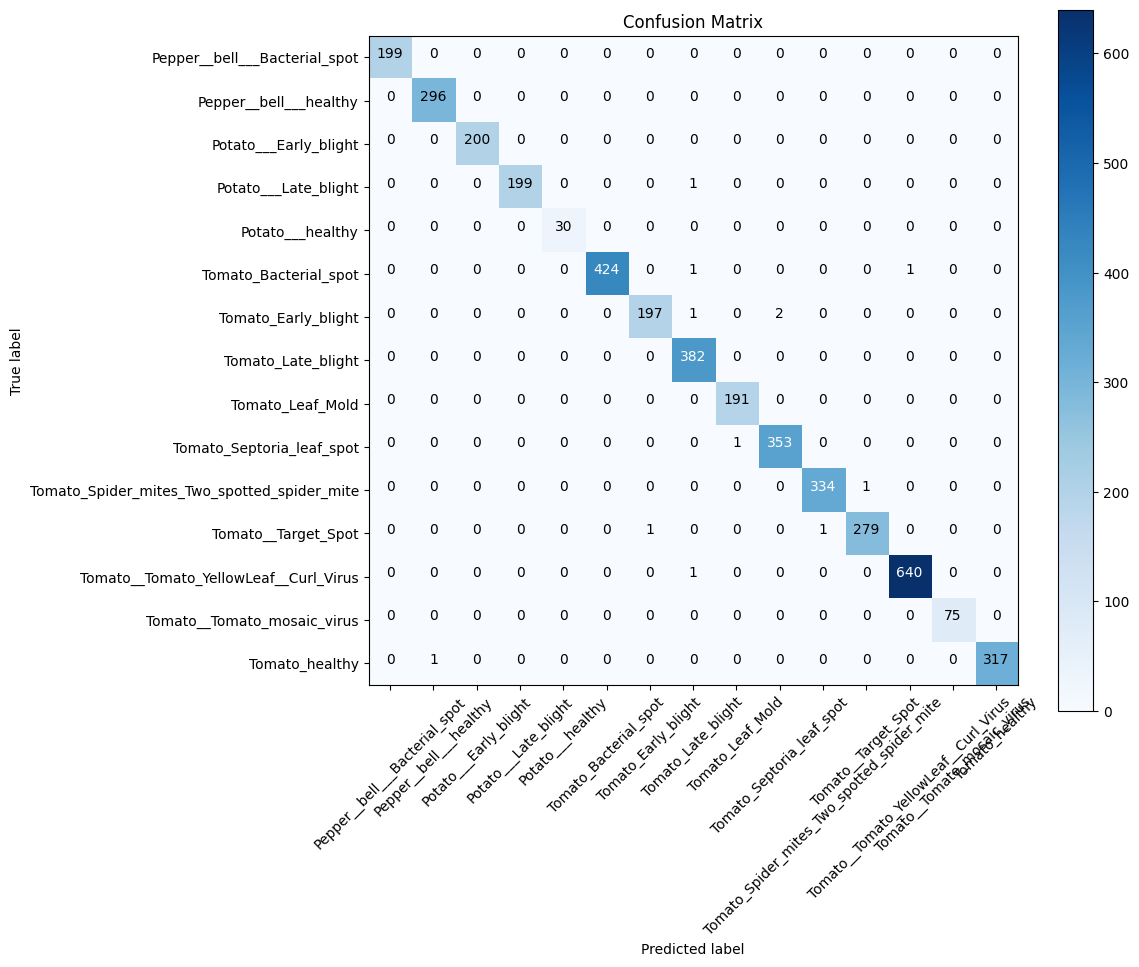

Normalized confusion matrix


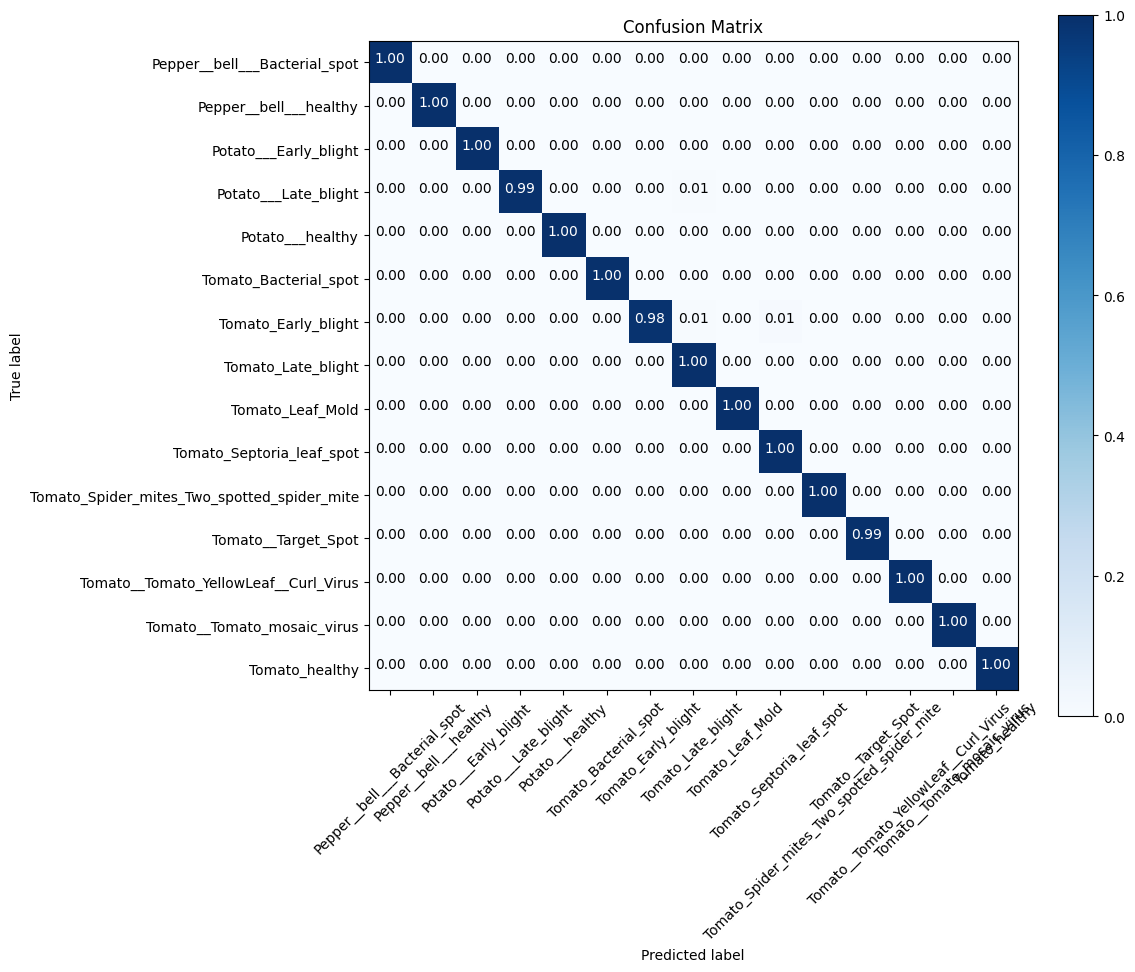

In [25]:
# Enhanced evaluation with progress bars
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

if 'model' in locals():
    print("🔍 Running Enhanced Model Evaluation")
    print("=" * 60)
    
    # Use the new evaluation function with progress bars
    test_loss, test_acc, y_pred_classes, y_true_classes = complete_evaluation(
        model, test_loader, nn.CrossEntropyLoss(), device, classes
    )
    
else:
    print("❌ Model not loaded. Please run the previous cell first.")

📊 Training History Visualization


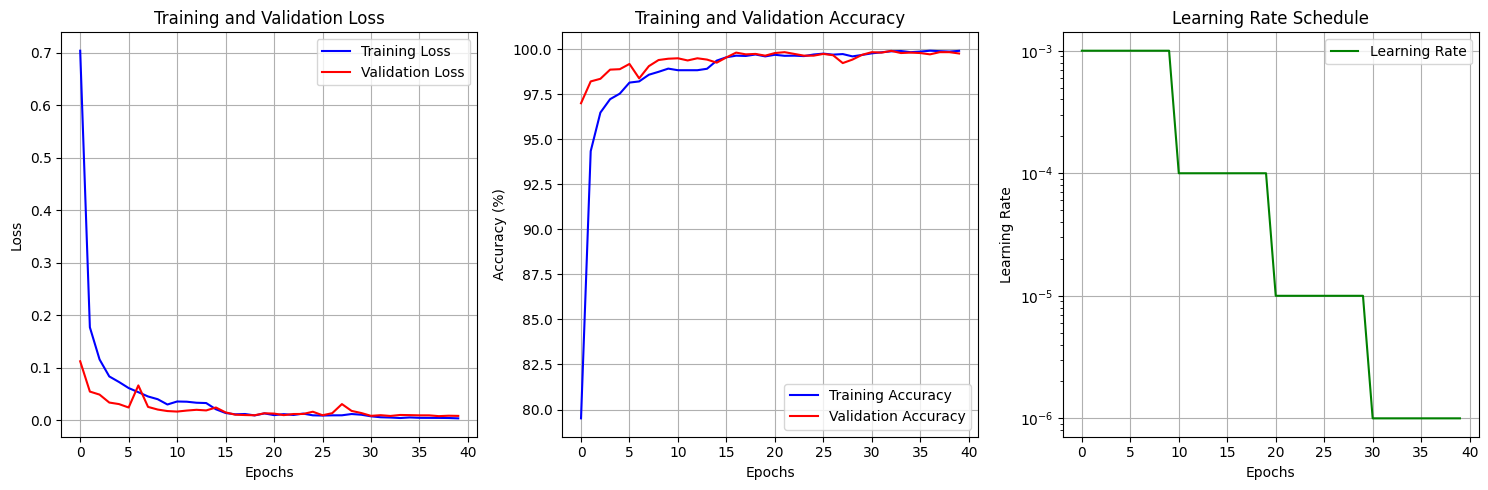

📈 Training Summary:
Final Training Accuracy: 99.90%
Final Validation Accuracy: 99.76%
Best Validation Accuracy: 99.90%
Final Training Loss: 0.0040
Final Validation Loss: 0.0087


In [26]:
# Visualize training results (run this after training)
if 'train_losses' in locals() and 'val_losses' in locals():
    print("📊 Training History Visualization")
    plot_training_history(train_losses, train_accs, val_losses, val_accs)
    
    print("📈 Training Summary:")
    print(f"Final Training Accuracy: {train_accs[-1]:.2f}%")
    print(f"Final Validation Accuracy: {val_accs[-1]:.2f}%")
    print(f"Best Validation Accuracy: {max(val_accs):.2f}%")
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")
else:
    print("Training history not available. Please run the training cell first.")

# Make Prediction

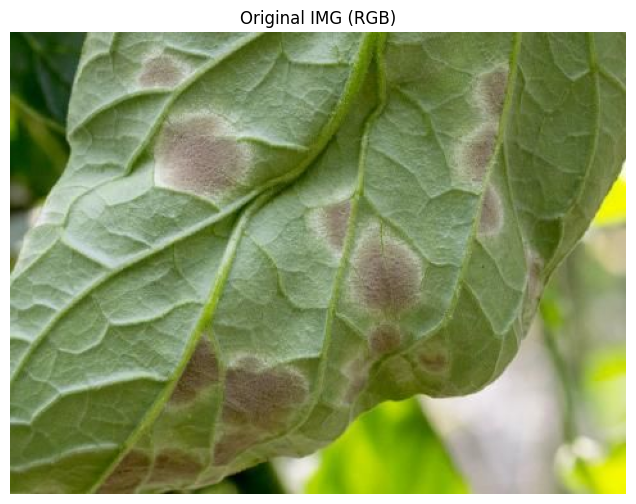

IMG: UK_advice-pests-diseases-tomato-leaf-mould_main.jpg
Real IMG: realImage
Prediction: Pepper__bell___healthy (0.9995)

Top 3 predictions:
1. Pepper__bell___healthy: 0.9995
2. Tomato_Late_blight: 0.0005
3. Tomato_healthy: 0.0000


In [31]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms

# image_path = "./realImage/late_blight_tomato_leaf5x12001-1.jpg"
image_path = "./realImage/UK_advice-pests-diseases-tomato-leaf-mould_main.jpg"

# Define preprocessing for single image - consistent with train.ipynb
single_image_transform = transforms.Compose([
    transforms.Resize((160, 160)),  # Match training size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if 'model' in locals() and os.path.exists(image_path):
    # Load and preprocess image
    img_rgb = Image.open(image_path).convert('RGB')
    img_tensor = single_image_transform(img_rgb).unsqueeze(0).to(device)  # Add batch dimension
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_idx = torch.argmax(probabilities, dim=1).item()
        confidence = probabilities[0][predicted_idx].item()
    
    # Display image
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title("Original IMG (RGB)")
    plt.axis('off')
    plt.show()
    
    # Display results
    print(f"IMG: {os.path.basename(image_path)}")
    print(f"Real IMG: {os.path.basename(os.path.dirname(image_path))}")
    print(f"Prediction: {classes[predicted_idx]} ({confidence:.4f})")
    
    # Show top 3 predictions
    top3_prob, top3_idx = torch.topk(probabilities[0], 3)
    print("\nTop 3 predictions:")
    for i in range(3):
        idx = top3_idx[i].item()
        prob = top3_prob[i].item()
        print(f"{i+1}. {classes[idx]}: {prob:.4f}")
else:
    if 'model' not in locals():
        print("Model not loaded. Please run the model loading cell first.")
    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")